<a href="https://colab.research.google.com/github/JhomaroGC/AnalisisDatos/blob/main/informeMercanciaRecibida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Configuración estética
PRIMARY_COLOR = "#E81E65"
sns.set_theme(style="white")

# Cargar datos
df = pd.read_csv('025.entradasBodegaArvi (1).csv')
df.head()

,ID,Title,id_inventario,Producto,Cantidad,Estado,Modified,Modified By,Attachments
0,493,20260107980289,3.302,SUDADERA TRANSFORMABLE GRIS MASC T: 38,1.0,Cargado,7/01/2026 15:28,Fabian Giraldo Vargas,0
1,492,20260107435473,2.704,CAMISETA GRIS TALLA S FEM,2.0,Cargado,7/01/2026 15:15,Fabian Giraldo Vargas,0
2,491,20260107435473,2.702,CAMISETA GRIS TALLA M FEM,2.0,Cargado,7/01/2026 15:15,Fabian Giraldo Vargas,0
3,490,20260107435473,2.700,CAMISETA GRIS TALLA L FEM,2.0,Cargado,7/01/2026 15:15,Fabian Giraldo Vargas,0
4,489,20260107435473,2.706,CAMISETA GRIS TALLA XL MASC,4.0,Cargado,7/01/2026 15:15,Fabian Giraldo Vargas,0


In [10]:
# Convertir columna de fecha a objeto datetime
df['Modified'] = pd.to_datetime(df['Modified'], dayfirst=True)

# Asegurar que 'Cantidad' sea numérico
df['Cantidad'] = pd.to_numeric(df['Cantidad'], errors='coerce').fillna(0)

# Extraer mes, año y día de la semana
df['Mes_Anio'] = df['Modified'].dt.to_period('M')
df['Nombre_Mes'] = df['Modified'].dt.month_name()
df['Dia_Semana'] = df['Modified'].dt.day_name()

# Diccionario para traducir días (opcional pero recomendado)
dias_map = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df['Dia_Semana'] = df['Dia_Semana'].map(dias_map)

In [3]:
total_recibidas = int(df['Cantidad'].sum())
pct_cargado = (df['Estado'] == 'Cargado').mean() * 100

# Encontrar el mes con mayor mercancía
resumen_mensual = df.groupby('Mes_Anio')['Cantidad'].sum()
mes_top = resumen_mensual.idxmax()
valor_top = resumen_mensual.max()

print(f"--- KPIs INFORME PRODUCTO ---")
print(f"Total Recibidas: {total_recibidas:,}")
print(f"Estado Cargado: {pct_cargado:.1f}%")
print(f"Mes Pico: {mes_top} ({int(valor_top)} unidades)")

--- KPIs INFORME PRODUCTO ---
Total Recibidas: 10,012
Estado Cargado: 99.3%
Mes Pico: 2025-07 (1945 unidades)


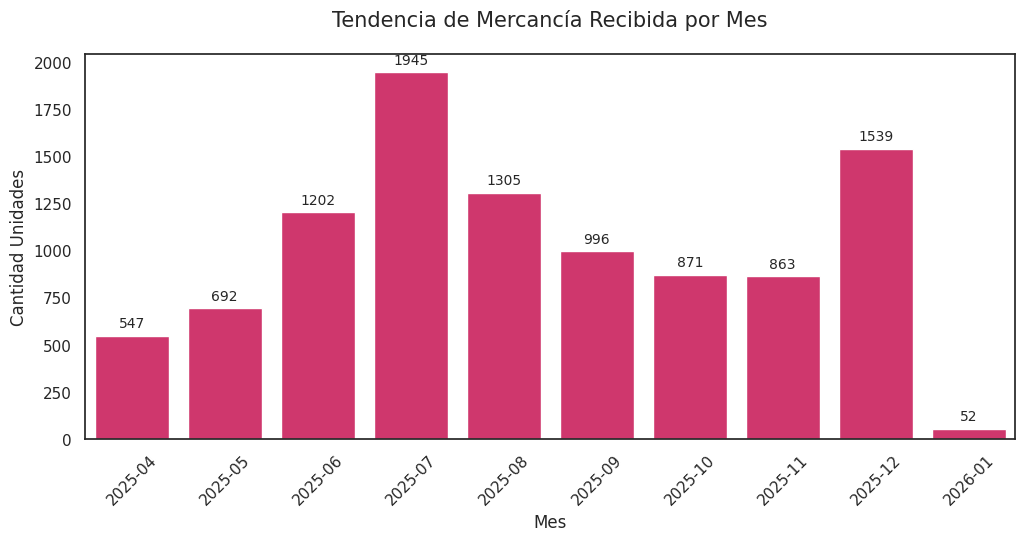

In [14]:
plt.figure(figsize=(12, 5))
trend_data = df.groupby('Mes_Anio')['Cantidad'].sum().reset_index()
trend_data['Mes_Anio'] = trend_data['Mes_Anio'].astype(str)

ax = sns.barplot(data=trend_data, x='Mes_Anio', y='Cantidad', color=PRIMARY_COLOR)
plt.title('Tendencia de Mercancía Recibida por Mes', fontsize=15, pad=20)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad Unidades', fontsize=12)
plt.xticks(rotation=45)

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

plt.show()

/tmp/ipython-input-466784422.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos.values, y=top_productos.index, ax=ax1, palette="light:#E81E65_r")


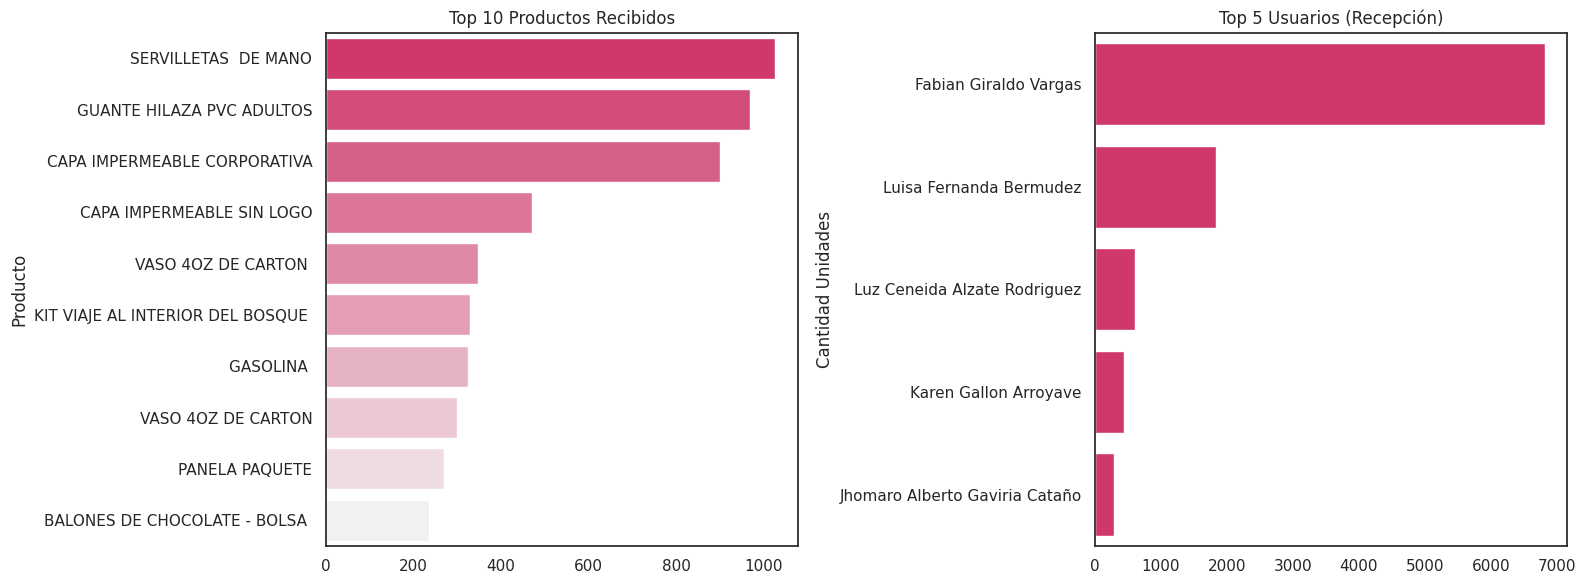

In [18]:
# Configurar una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top Productos
top_productos = df.groupby('Producto')['Cantidad'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_productos.values, y=top_productos.index, ax=ax1, palette="light:#E81E65_r")
ax1.set_title('Top 10 Productos Recibidos')
ax1.set_label('Cantidad Unidades')

# Top Usuarios
top_usuarios = df.groupby('Modified By')['Cantidad'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_usuarios.values, y=top_usuarios.index, ax=ax2, color=PRIMARY_COLOR)
ax2.set_title('Top 5 Usuarios (Recepción)')
ax2.set_ylabel('Cantidad Unidades')

# Ajustar espaciado entre subgráficos


plt.tight_layout()
plt.show()

<Axes: xlabel='Dia_Semana'>

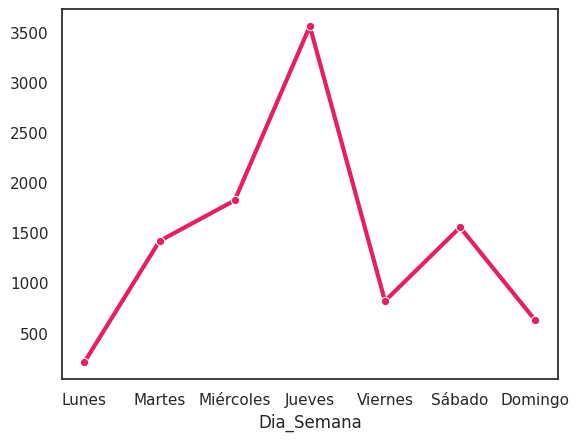

In [13]:
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
data_dias = df.groupby('Dia_Semana')['Cantidad'].sum().reindex(orden_dias)

plt.figure(figsize=(10, 4))
sns.lineplot(x=data_dias.index, y=data_dias.values, marker='o', color=PRIMARY_COLOR, linewidth=3)
plt.fill_between(data_dias.index, data_dias.values, color=PRIMARY_COLOR, alpha=0.1)
plt.title('Distribución de Recepción por Día de la Semana')
plt.ylabel('Cantidad Unidades')
plt.show()